
Loaded analysis data
Current range: -6.0 to 6.0 mA
Frequency range: 6.51 to 6.76 GHz
data_2d shape: (121, 1001)


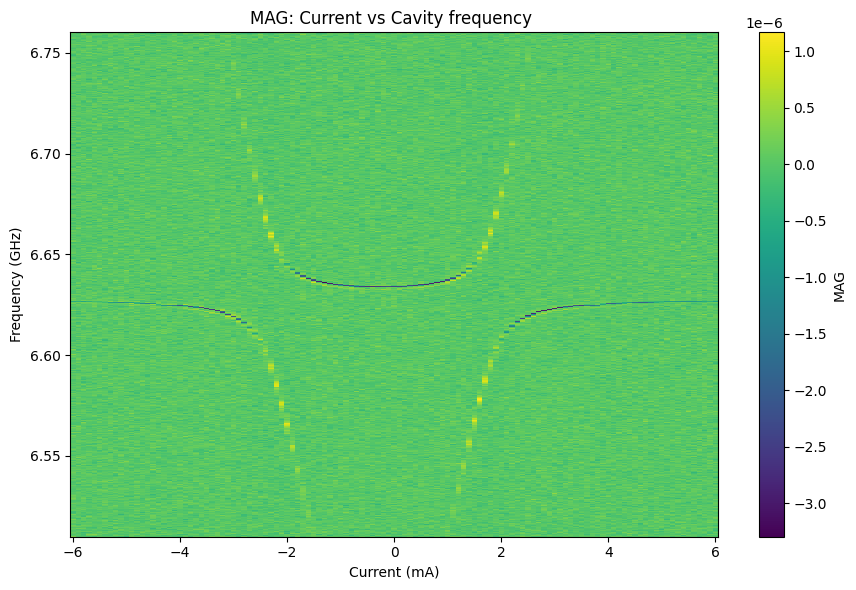

In [1]:
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# USER SETTINGS
# ==========================================================

build_npz_from_hdf5 = False
load_npz_for_analysis = True

current_A_print2 = np.linspace(
    start=-6e-3,
    stop=6e-3,
    num=121,
)

lo = 6.61e9 + 50e6  # Hz

batches = [
    {
        "date": "2026-08-09",
        "folder": r"C:\Users\qcrew\Desktop\Juncheng\victoria\data\2026-08-09",
        "time": ((16, 0), (23, 59)),
        "current": current_A_print2[0:89],
        "lo": lo,
    },
    {
        "date": "2026-08-10",
        "folder": r"C:\Users\qcrew\Desktop\Juncheng\victoria\data\2026-08-10",
        "time": ((0, 0), (2, 50)),
        "current": current_A_print2[89:121],
        "lo": lo,
    },
]

file_key = "CavitySpec_versus_flux"

plot_data = "MAG"          # "I", "Q", or "MAG"

y_key = None               # None -> auto-choose sweep axis

subtract_mean = True

x_label = "Current"
y_label = "Cavity frequency"

show_individual_plots = False
plot_current_in_mA = True

output_folder = (
    r"C:\Users\qcrew\Desktop\Juncheng\victoria\scripts"
    r"\plot\data_plot_data"
)

os.makedirs(output_folder, exist_ok=True)


# ==========================================================
# OUTPUT NPZ NAME
# ==========================================================

st_d = batches[0]["date"].replace("-", "")
end_d = batches[-1]["date"].replace("-", "")

st_h, st_m = batches[0]["time"][0]
end_h, end_m = batches[-1]["time"][1]

save_npz_name = (
    f"{file_key}_"
    f"{st_d}_{st_h:02d}{st_m:02d}_"
    f"to_"
    f"{end_d}_{end_h:02d}{end_m:02d}_"
    f"{plot_data}.npz"
)

npz_path = os.path.join(
    output_folder,
    save_npz_name,
)


# ==========================================================
# TRACE SETTINGS
# ==========================================================

find_mode = "min"          # "min" or "max"

remove_outliers = True
jump_threshold = 0.005     # GHz if trace is converted to GHz

save_min_trace = True


# ==========================================================
# HELPER FUNCTIONS
# ==========================================================

def extract_time(filename):
    """
    Extract HH-MM from filenames beginning with e.g.
    18-53-32_CavitySpec_versus_flux...
    """

    try:
        parts = os.path.basename(filename).split("-")

        hour = int(parts[0])
        minute = int(parts[1])

        return hour, minute

    except Exception:
        return -1, -1


def get_filtered_files(
    folder,
    start_time,
    end_time,
    file_key,
):
    """
    Find HDF5 files containing file_key and lying
    inside the requested HH:MM time interval.
    """

    if not os.path.exists(folder):
        print(f"Folder not found: {folder}")
        return []

    files = [
        os.path.join(folder, f)
        for f in os.listdir(folder)
        if (
            f.endswith(".hdf5")
            and file_key in f
        )
    ]

    filtered = [
        f
        for f in files
        if start_time <= extract_time(f) <= end_time
    ]

    return sorted(
        filtered,
        key=extract_time,
    )


def load_one_hdf5(
    filename,
    y_key=None,
    subtract_mean=True,
):
    """
    Load one cavity spectroscopy HDF5 file.

    Returns
    -------
    key
        Name of sweep-axis dataset.

    y_vals
        Sweep-axis values.

    I_val
        Averaged I trace.

    Q_val
        Averaged Q trace.

    mag_val
        Averaged magnitude trace.
    """

    with h5py.File(filename, "r") as f:

        # ----------------------------------------------
        # Determine sweep-axis key automatically
        # ----------------------------------------------

        if y_key is None:

            candidate_keys = [
                k
                for k in f.keys()
                if k not in {
                    "I",
                    "Q",
                    "Magnitude",
                }
            ]

            if len(candidate_keys) == 0:
                raise ValueError(
                    f"No sweep axis found in:\n{filename}"
                )

            key = candidate_keys[0]

        else:
            key = y_key

        y_vals = np.asarray(
            f[key][()]
        ).squeeze()

        # ----------------------------------------------
        # Load I and Q
        # ----------------------------------------------

        I_raw = np.asarray(
            f["I"][()]
        )

        Q_raw = np.asarray(
            f["Q"][()]
        )

        # Average repetitions / acquisition samples
        if I_raw.ndim > 1:
            I_val = np.mean(
                I_raw,
                axis=0,
            )
        else:
            I_val = I_raw

        if Q_raw.ndim > 1:
            Q_val = np.mean(
                Q_raw,
                axis=0,
            )
        else:
            Q_val = Q_raw

        # ----------------------------------------------
        # Magnitude
        # ----------------------------------------------

        if "Magnitude" in f:

            mag_raw = np.asarray(
                f["Magnitude"][()]
            )

            if mag_raw.ndim > 1:
                mag_val = np.mean(
                    mag_raw,
                    axis=0,
                )
            else:
                mag_val = mag_raw

        else:
            mag_val = np.sqrt(
                I_val**2
                + Q_val**2
            )

        # ----------------------------------------------
        # Flatten
        # ----------------------------------------------

        I_val = np.asarray(I_val).squeeze()
        Q_val = np.asarray(Q_val).squeeze()
        mag_val = np.asarray(mag_val).squeeze()

        # ----------------------------------------------
        # Background subtraction
        # ----------------------------------------------

        if subtract_mean:
            I_val = I_val - np.mean(I_val)
            Q_val = Q_val - np.mean(Q_val)
            mag_val = mag_val - np.mean(mag_val)

    return (
        key,
        y_vals,
        I_val,
        Q_val,
        mag_val,
    )


def base_mesh_plot(
    x,
    y,
    z,
    title_suffix="",
):
    """
    Standard 2D spectroscopy mesh plot.
    """

    plt.figure(
        figsize=(9, 6)
    )

    if plot_current_in_mA:
        x_plot = np.asarray(x) * 1e3
        x_unit = "mA"
    else:
        x_plot = np.asarray(x)
        x_unit = "A"

    plt.pcolormesh(
        x_plot,
        y / 1e9,
        z.T,
        shading="auto",
        cmap="viridis",
    )

    plt.xlabel(
        f"{x_label} ({x_unit})"
    )

    plt.ylabel(
        "Frequency (GHz)"
    )

    plt.title(
        f"{plot_data}: "
        f"{x_label} vs {y_label} "
        f"{title_suffix}"
    )

    plt.colorbar(
        label=plot_data
    )

    plt.tight_layout()


# ==========================================================
# BUILD NPZ FROM HDF5
# ==========================================================

if build_npz_from_hdf5:

    grouped_files = []
    x_values = []

    file_dates = []
    file_times = []

    # ----------------------------------------------
    # Collect files from all batches
    # ----------------------------------------------

    for b in batches:

        files = get_filtered_files(
            b["folder"],
            b["time"][0],
            b["time"][1],
            file_key,
        )

        n = min(
            len(files),
            len(b["current"]),
        )

        print()
        print("=" * 70)
        print(
            f"Date: {b['date']}"
        )
        print(
            f"Found {len(files)} files"
        )
        print(
            f"Using {n} files"
        )

        grouped_files.extend(
            files[:n]
        )

        x_values.extend(
            b["current"][:n]
        )

        file_dates.extend(
            [b["date"]] * n
        )

        file_times.extend(
            [
                extract_time(f)
                for f in files[:n]
            ]
        )

    if not grouped_files:
        raise ValueError(
            "No matching HDF5 files found."
        )

    # ----------------------------------------------
    # Read all spectroscopy traces
    # ----------------------------------------------

    I_2d = []
    Q_2d = []
    MAG_2d = []

    sweep_axis = []

    for i, fname in enumerate(grouped_files):

        print(
            f"[{i + 1:03d}/{len(grouped_files):03d}] "
            f"{os.path.basename(fname)}"
        )

        (
            key,
            y_vals,
            I_v,
            Q_v,
            M_v,
        ) = load_one_hdf5(
            fname,
            y_key,
            subtract_mean,
        )

        sweep_axis.append(
            y_vals
        )

        I_2d.append(
            I_v
        )

        Q_2d.append(
            Q_v
        )

        MAG_2d.append(
            M_v
        )

    # ----------------------------------------------
    # Convert lists to arrays
    # ----------------------------------------------

    x_values = np.asarray(
        x_values,
        dtype=float,
    )

    sweep_axis = np.asarray(
        sweep_axis
    )

    I_2d = np.asarray(
        I_2d
    )

    Q_2d = np.asarray(
        Q_2d
    )

    MAG_2d = np.asarray(
        MAG_2d
    )

    # Assume sweep axes are identical
    y_values = sweep_axis[0]

    print()
    print("Final array shapes")
    print("------------------")
    print(
        "current:",
        x_values.shape,
    )
    print(
        "frequency:",
        y_values.shape,
    )
    print(
        "I:",
        I_2d.shape,
    )
    print(
        "Q:",
        Q_2d.shape,
    )
    print(
        "MAG:",
        MAG_2d.shape,
    )

    # ----------------------------------------------
    # Save NPZ
    # ----------------------------------------------

    np.savez_compressed(
        npz_path,

        x_values=x_values,

        current=x_values,

        current_mA=(
            x_values * 1e3
        ),

        y_values=y_values,

        cav_if=y_values,

        sweep_axis=sweep_axis,

        I=I_2d,

        Q=Q_2d,

        MAG=MAG_2d,

        x_label=x_label,

        y_label=y_label,

        y_key=key,

        filenames=grouped_files,

        file_dates=file_dates,

        file_times=file_times,

        batch_dates=[
            b["date"]
            for b in batches
        ],

        batch_start_times=[
            b["time"][0]
            for b in batches
        ],

        batch_end_times=[
            b["time"][1]
            for b in batches
        ],

        batch_folders=[
            b["folder"]
            for b in batches
        ],

        file_key=file_key,

        subtract_mean=subtract_mean,

        plot_data_saved=plot_data,
    )

    print()
    print(
        f"Saved main NPZ to:\n{npz_path}"
    )


# ==========================================================
# ANALYSIS
# ==========================================================

if load_npz_for_analysis:

    data = np.load(
        npz_path,
        allow_pickle=True,
    )

    x_values = np.asarray(
        data["current"],
        dtype=float,
    )

    # ----------------------------------------------
    # Convert IF frequency to absolute frequency
    # ----------------------------------------------

    if "cav_if" in data.keys():

        y_values = (
            np.asarray(
                data["cav_if"],
                dtype=float,
            )
            + lo
        )

    else:

        y_values = np.asarray(
            data["y_values"],
            dtype=float,
        )

    data_2d = np.asarray(
        data[plot_data],
        dtype=float,
    )

    print()
    print("=" * 70)
    print("Loaded analysis data")
    print("=" * 70)

    print(
        "Current range:",
        x_values.min() * 1e3,
        "to",
        x_values.max() * 1e3,
        "mA",
    )

    print(
        "Frequency range:",
        y_values.min() / 1e9,
        "to",
        y_values.max() / 1e9,
        "GHz",
    )

    print(
        "data_2d shape:",
        data_2d.shape,
    )


    # ======================================================
    # RAW 2D MESH
    # ======================================================

    base_mesh_plot(
        x_values,
        y_values,
        data_2d,
    )

    plt.show()


    # ======================================================
    # FIND MIN / MAX FREQUENCY AT EACH CURRENT
    # ======================================================

    if find_mode == "min":

        idx = np.argmin(
            data_2d,
            axis=1,
        )

    elif find_mode == "max":

        idx = np.argmax(
            data_2d,
            axis=1,
        )

    else:

        raise ValueError(
            "find_mode must be 'min' or 'max'"
        )

    trace_y = y_values[idx]

    trace_val = data_2d[
        np.arange(
            data_2d.shape[0]
        ),
        idx,
    ]


    

In [16]:
# ==========================================================
# FIND MAX AND MIN FOR EACH CURRENT
# ==========================================================

current_mA = np.asarray(x_values) * 1e3
freq_GHz = np.asarray(y_values) / 1e9

# Frequency region to search
freq_min_GHz = 6.57
freq_max_GHz = 6.68

mask = (
    (freq_GHz >= freq_min_GHz)
    & (freq_GHz <= freq_max_GHz)
)

f = freq_GHz[mask]
Z = data_2d[:, mask]

# Index of absolute maximum/minimum for every current
idx_max = np.argmax(Z, axis=1)
idx_min = np.argmin(Z, axis=1)

# Corresponding frequencies
freq_max = f[idx_max]
freq_min = f[idx_min]

# Corresponding MAG values
value_max = Z[np.arange(len(current_mA)), idx_max]
value_min = Z[np.arange(len(current_mA)), idx_min]

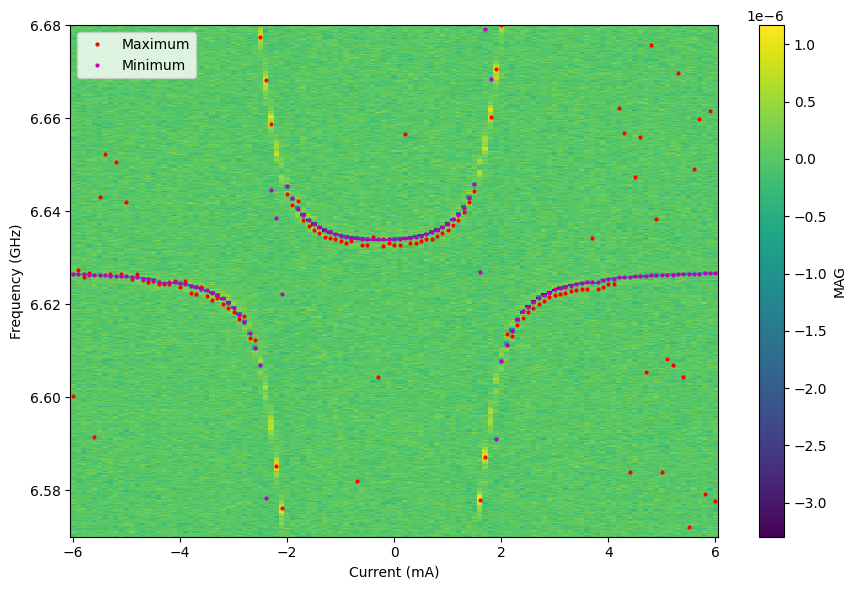

In [17]:
fig, ax = plt.subplots(figsize=(9, 6))

mesh = ax.pcolormesh(
    current_mA,
    freq_GHz,
    data_2d.T,
    shading="auto",
    cmap="viridis",
)

ax.plot(
    current_mA,
    freq_max,
    "r.",
    markersize=4,
    label="Maximum",
)

ax.plot(
    current_mA,
    freq_min,
    "m.",
    markersize=4,
    label="Minimum",
)

ax.set_xlabel("Current (mA)")
ax.set_ylabel("Frequency (GHz)")

ax.set_ylim(
    freq_min_GHz,
    freq_max_GHz,
)

fig.colorbar(
    mesh,
    ax=ax,
    label=plot_data,
)

ax.legend()
plt.tight_layout()
plt.show()

In [18]:
# ==========================================================
# DISCARD DISCONTINUOUS POINTS
# ==========================================================

max_jump_MHz = 5.0


def remove_discontinuous_points(freq_GHz, max_jump_MHz=5.0):
    """
    Remove isolated frequency points that are inconsistent
    with both neighboring current points.
    """

    freq_GHz = np.asarray(freq_GHz, dtype=float)
    cleaned = freq_GHz.copy()

    threshold = max_jump_MHz / 1000.0  # MHz -> GHz

    for i in range(1, len(freq_GHz) - 1):

        f_prev = freq_GHz[i - 1]
        f_now  = freq_GHz[i]
        f_next = freq_GHz[i + 1]

        if not (
            np.isfinite(f_prev)
            and np.isfinite(f_now)
            and np.isfinite(f_next)
        ):
            continue

        jump_left = abs(f_now - f_prev)
        jump_right = abs(f_now - f_next)

        # Neighbors should themselves look reasonably continuous
        neighbor_difference = abs(f_next - f_prev)

        if (
            jump_left > threshold
            and jump_right > threshold
            and neighbor_difference < 2 * threshold
        ):
            cleaned[i] = np.nan

    return cleaned


freq_max_clean = remove_discontinuous_points(
    freq_max,
    max_jump_MHz=max_jump_MHz,
)

freq_min_clean = remove_discontinuous_points(
    freq_min,
    max_jump_MHz=max_jump_MHz,
)

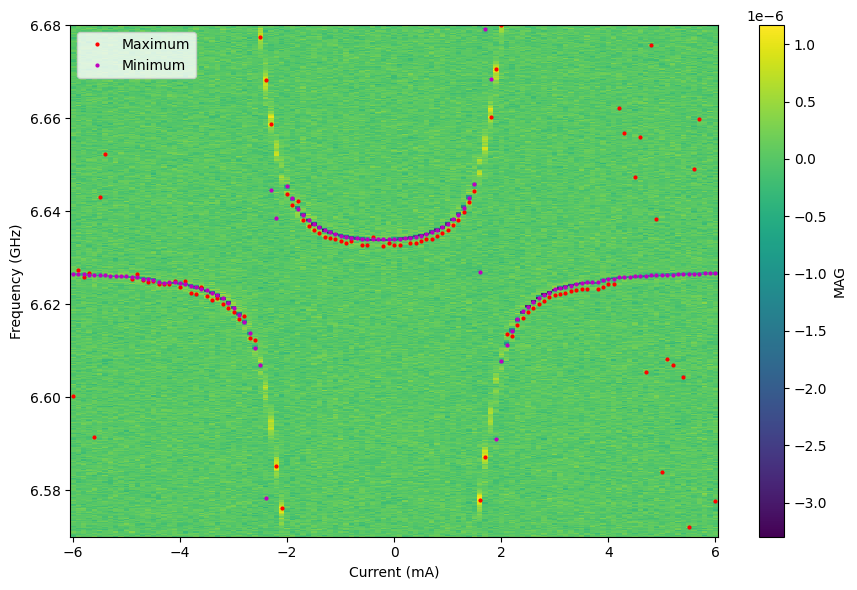

In [19]:
fig, ax = plt.subplots(figsize=(9, 6))

mesh = ax.pcolormesh(
    current_mA,
    freq_GHz,
    data_2d.T,
    shading="auto",
    cmap="viridis",
)

ax.plot(
    current_mA,
    freq_max_clean,
    "r.",
    markersize=4,
    label="Maximum",
)

ax.plot(
    current_mA,
    freq_min_clean,
    "m.",
    markersize=4,
    label="Minimum",
)

ax.set_xlabel("Current (mA)")
ax.set_ylabel("Frequency (GHz)")

ax.set_ylim(
    freq_min_GHz,
    freq_max_GHz,
)

fig.colorbar(
    mesh,
    ax=ax,
    label=plot_data,
)

ax.legend()
plt.tight_layout()
plt.show()

Requested current: -2.000 mA
Actual current:    -2.000 mA


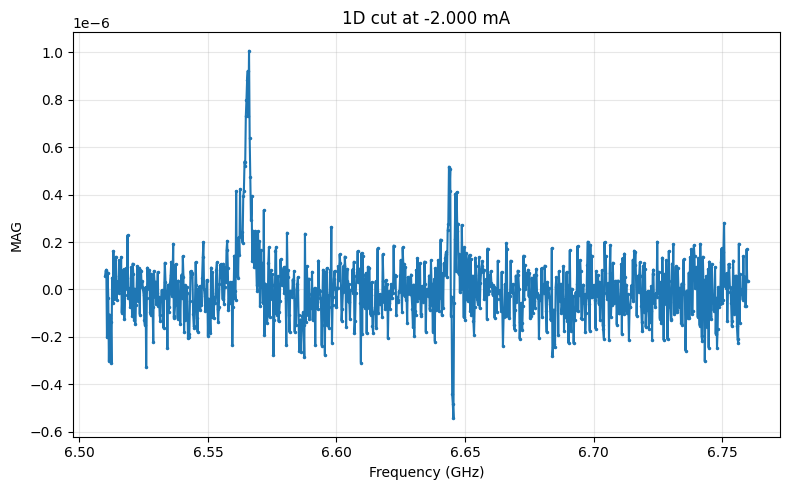

In [13]:
# ==========================================================
# 1D CUT AT -2 mA
# ==========================================================

target_current_mA = -2

current_mA = np.asarray(x_values) * 1e3
freq_GHz = np.asarray(y_values) / 1e9

# Find nearest measured current
i_cut = np.argmin(np.abs(current_mA - target_current_mA))

actual_current_mA = current_mA[i_cut]
spectrum = data_2d[i_cut, :]

print(f"Requested current: {target_current_mA:.3f} mA")
print(f"Actual current:    {actual_current_mA:.3f} mA")

plt.figure(figsize=(8, 5))

plt.plot(
    freq_GHz,
    spectrum,
    ".-",
    markersize=3,
)

plt.xlabel("Frequency (GHz)")
plt.ylabel(plot_data)
plt.title(f"1D cut at {actual_current_mA:.3f} mA")

# plt.xlim(6.59, 6.66)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Requested current : 2.000 mA
Actual current    : 2.000 mA

Peak frequency    : 6.609250000 GHz
Dip frequency     : 6.607750000 GHz

Lower frequency   : 6.607750000 GHz
Upper frequency   : 6.609250000 GHz
Splitting         : 1.500 MHz


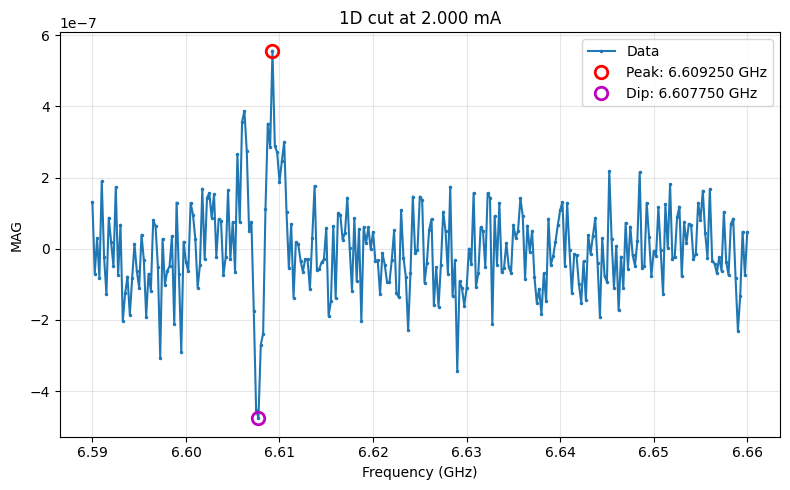

In [6]:
from scipy.signal import find_peaks
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# 1D CUT AT -2 mA: ONE PEAK + ONE DIP
# ==========================================================

target_current_mA = 2.0

# Frequency window of interest
freq_min_GHz = 6.59
freq_max_GHz = 6.66

current_mA = np.asarray(x_values) * 1e3
freq_GHz = np.asarray(y_values) / 1e9

# Nearest measured current
i_cut = np.argmin(
    np.abs(current_mA - target_current_mA)
)

actual_current_mA = current_mA[i_cut]
spectrum = data_2d[i_cut, :]

# Restrict to anticrossing region
mask = (
    (freq_GHz >= freq_min_GHz)
    & (freq_GHz <= freq_max_GHz)
)

f = freq_GHz[mask]
s = spectrum[mask]

# ==========================================================
# FIND PEAK
# ==========================================================

peaks, peak_props = find_peaks(
    s,
    prominence=0,
    distance=3,
)

if len(peaks) > 0:
    # Most prominent positive peak
    i_peak_local = peaks[
        np.argmax(peak_props["prominences"])
    ]

    f_peak = f[i_peak_local]
    y_peak = s[i_peak_local]

else:
    f_peak = np.nan
    y_peak = np.nan


# ==========================================================
# FIND DIP
# ==========================================================

dips, dip_props = find_peaks(
    -s,
    prominence=0,
    distance=3,
)

if len(dips) > 0:
    # Most prominent dip
    i_dip_local = dips[
        np.argmax(dip_props["prominences"])
    ]

    f_dip = f[i_dip_local]
    y_dip = s[i_dip_local]

else:
    f_dip = np.nan
    y_dip = np.nan


# ==========================================================
# PRINT RESULTS
# ==========================================================

print(f"Requested current : {target_current_mA:.3f} mA")
print(f"Actual current    : {actual_current_mA:.3f} mA")
print()

print(f"Peak frequency    : {f_peak:.9f} GHz")
print(f"Dip frequency     : {f_dip:.9f} GHz")

if np.isfinite(f_peak) and np.isfinite(f_dip):

    freq_lower = min(f_peak, f_dip)
    freq_upper = max(f_peak, f_dip)

    print()
    print(f"Lower frequency   : {freq_lower:.9f} GHz")
    print(f"Upper frequency   : {freq_upper:.9f} GHz")
    print(
        f"Splitting         : "
        f"{(freq_upper - freq_lower) * 1e3:.3f} MHz"
    )


# ==========================================================
# PLOT
# ==========================================================

plt.figure(figsize=(8, 5))

plt.plot(
    f,
    s,
    ".-",
    markersize=3,
    label="Data",
)

if np.isfinite(f_peak):
    plt.plot(
        f_peak,
        y_peak,
        "ro",
        markersize=9,
        markerfacecolor="none",
        markeredgewidth=2,
        label=f"Peak: {f_peak:.6f} GHz",
    )

if np.isfinite(f_dip):
    plt.plot(
        f_dip,
        y_dip,
        "mo",
        markersize=9,
        markerfacecolor="none",
        markeredgewidth=2,
        label=f"Dip: {f_dip:.6f} GHz",
    )

plt.xlabel("Frequency (GHz)")
plt.ylabel(plot_data)

plt.title(
    f"1D cut at {actual_current_mA:.3f} mA"
)

# plt.xlim(
#     freq_min_GHz,
#     freq_max_GHz,
# )

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()